In [5]:
import torch
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
def get_deeplab():
    model = torchvision.models.segmentation.deeplabv3_resnet101(pretrained=True).to(device)
    model.eval()
    return model

In [7]:
PALETTE = np.array([
    [0,0,0], [128,0,0], [0,128,0], [128,128,0], [0,0,128],
    [128,0,128], [0,128,128], [128,128,128], [64,0,0], [192,0,0],
    [64,128,0], [192,128,0], [64,0,128], [192,0,128], [64,128,128],
    [192,128,128], [0,64,0], [128,64,0], [0,192,0], [128,192,0], 
], dtype=np.uint8)

In [8]:
def preprocess(img_pil):
    transform = T.Compose([
        T.Resize(520),
        T.ToTensor(),
        T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    return transform(img_pil).unsqueeze(0)

def postprocess(output_tensor):
    out = output_tensor['out'][0].argmax(0).cpu().numpy()  
    return out

In [9]:
def visualize_mask_on_image(img_pil, mask, alpha=0.5):
    img = np.array(img_pil).astype(np.uint8)
    h,w = mask.shape
    palette = PALETTE
    color_mask = np.zeros((h,w,3), dtype=np.uint8)
    for cls in np.unique(mask):
        color_mask[mask==cls] = palette[cls % len(palette)]
    overlay = (img * (1-alpha) + color_mask * alpha).astype(np.uint8)
    plt.figure(figsize=(12,6))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Original"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(color_mask); plt.title("Segmentation Mask"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(overlay); plt.title("Overlay (50%)"); plt.axis('off')
    plt.tight_layout()
    plt.show()

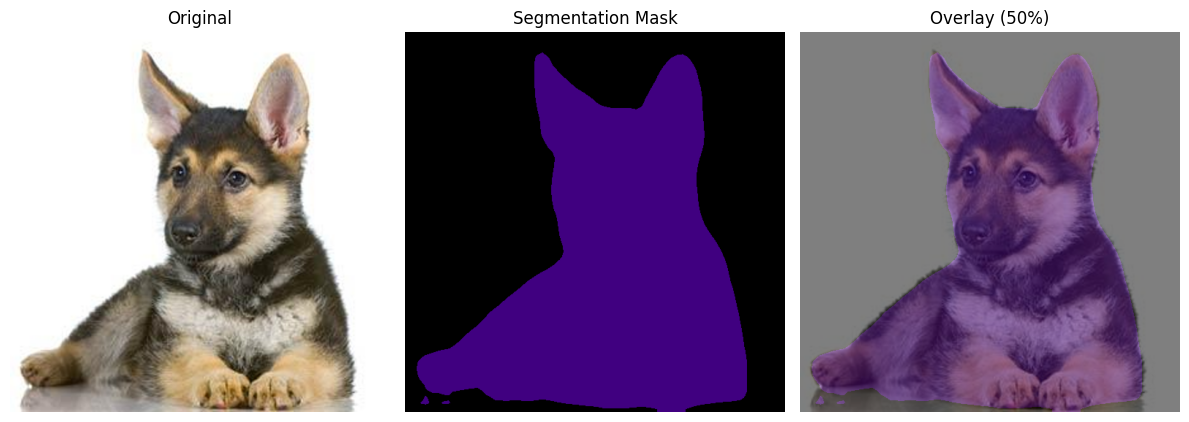

In [10]:
model = get_deeplab()
img = Image.open("dog.jpeg").convert("RGB")
inp = preprocess(img).to(device)
with torch.no_grad():
        out = model(inp)
mask = postprocess(out)
visualize_mask_on_image(img.resize((mask.shape[1], mask.shape[0])), mask)